<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/BasicAioperationonthebatteryandlocationdatasets23/4/2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AI/ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [2]:
from google.colab import files

# Upload files interactively
uploaded = files.upload()

# Example: load Battery and Location datasets
battery_df = pd.read_csv("Battery.csv")
location_df = pd.read_csv("Location.csv")

# Preview
print(battery_df.head())
print(location_df.head())


Saving Battery.csv to Battery (1).csv
Saving Location.csv to Location (1).csv
                  time  seconds_elapsed  batteryLevel batteryState  \
0  1752154082404000000            1.002          0.69    unplugged   
1  1752154083405000000            2.003          0.69    unplugged   
2  1752154084406000000            3.004          0.69    unplugged   
3  1752154085407000000            4.005          0.69    unplugged   
4  1752154086409000000            5.007          0.69    unplugged   

   lowPowerMode  
0         False  
1         False  
2         False  
3         False  
4         False  
                  time  seconds_elapsed  bearingAccuracy  speedAccuracy  \
0  1752154081995974100         0.593974       179.899994            2.5   
1  1752154082493578800         1.091579         0.000000            1.6   
2  1752154083221297700         1.819298        73.400002            1.2   
3  1752154083715330300         2.313330        55.799999            1.0   
4  175215408421817

In [6]:
# Convert time column to datetime if needed
print("Checking Null Values in the dataset\n")
battery_df['time'] = pd.to_datetime(battery_df['time'], errors='coerce')

# Check for nulls
print("Battery nulls:\n", battery_df.isnull().sum())
print(" \n")
print("Location nulls:\n", location_df.isnull().sum())

# Align datasets on seconds_elapsed
merged_df = pd.merge_asof(location_df.sort_values('seconds_elapsed'),
                          battery_df.sort_values('seconds_elapsed'),
                          on='seconds_elapsed')


Checking Null Values in the dataset

Battery nulls:
 time               0
seconds_elapsed    0
batteryLevel       0
batteryState       0
lowPowerMode       0
dtype: int64
 

Location nulls:
 time                  0
seconds_elapsed       0
bearingAccuracy       0
speedAccuracy         0
verticalAccuracy      0
horizontalAccuracy    0
speed                 0
bearing               0
altitude              0
longitude             0
latitude              0
dtype: int64


    seconds_elapsed  batteryLevel  discharge_rate
0             1.002          0.69             NaN
1             2.003          0.69             0.0
2             3.004          0.69             0.0
3             4.005          0.69             0.0
4             5.007          0.69             0.0
5             6.008          0.69             0.0
6             7.011          0.69             0.0
7             8.012          0.69             0.0
8             9.012          0.69             0.0
9            10.013          0.69             0.0
10           11.014          0.69             0.0
11           12.015          0.69             0.0
12           13.017          0.69             0.0
13           14.020          0.69             0.0
14           15.021          0.69             0.0
    seconds_elapsed     speed  speed_avg
0          0.593974  0.124766        NaN
1          1.091579  0.032038        NaN
2          1.819298  0.315866        NaN
3          2.313330  0.503440       

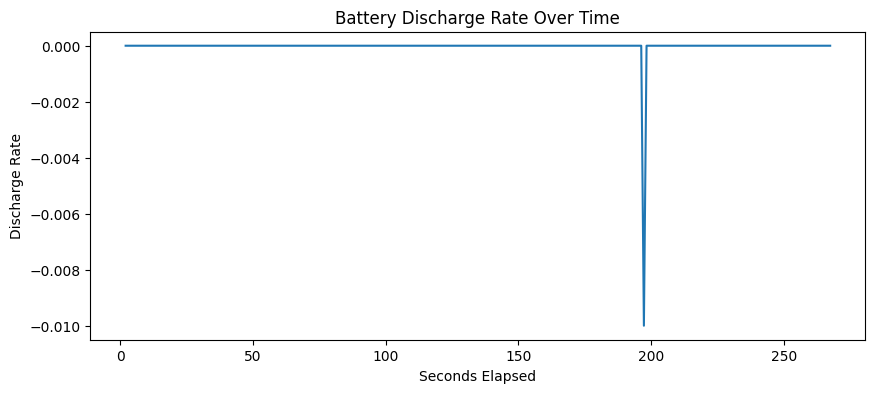

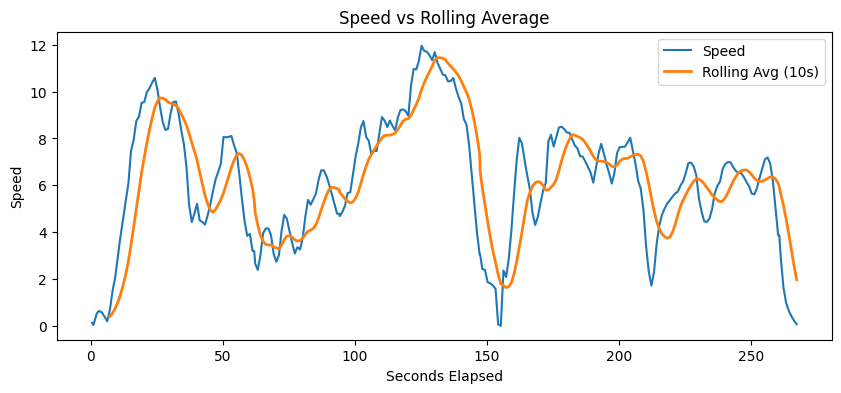

In [8]:
# Battery discharge rate
battery_df['discharge_rate'] = battery_df['batteryLevel'].diff() / battery_df['seconds_elapsed'].diff()

# Rolling speed average
location_df['speed_avg'] = location_df['speed'].rolling(window=10).mean()

# Merge again with engineered features
merged_df = pd.merge_asof(location_df.sort_values('seconds_elapsed'),
                          battery_df.sort_values('seconds_elapsed'),
                          on='seconds_elapsed')
# Inspect new columns
print(battery_df[['seconds_elapsed','batteryLevel','discharge_rate']].head(15))

print(location_df[['seconds_elapsed','speed','speed_avg']].head(15))

# Check merged dataset
print(merged_df.head())

# Battery discharge rate over time
plt.figure(figsize=(10,4))
plt.plot(battery_df['seconds_elapsed'], battery_df['discharge_rate'])
plt.title("Battery Discharge Rate Over Time")
plt.xlabel("Seconds Elapsed")
plt.ylabel("Discharge Rate")
plt.show()

# Speed with rolling average
plt.figure(figsize=(10,4))
plt.plot(location_df['seconds_elapsed'], location_df['speed'], label="Speed")
plt.plot(location_df['seconds_elapsed'], location_df['speed_avg'], label="Rolling Avg (10s)", linewidth=2)
plt.title("Speed vs Rolling Average")
plt.xlabel("Seconds Elapsed")
plt.ylabel("Speed")
plt.legend()
plt.show()


PCA Dimensionality Reduction 



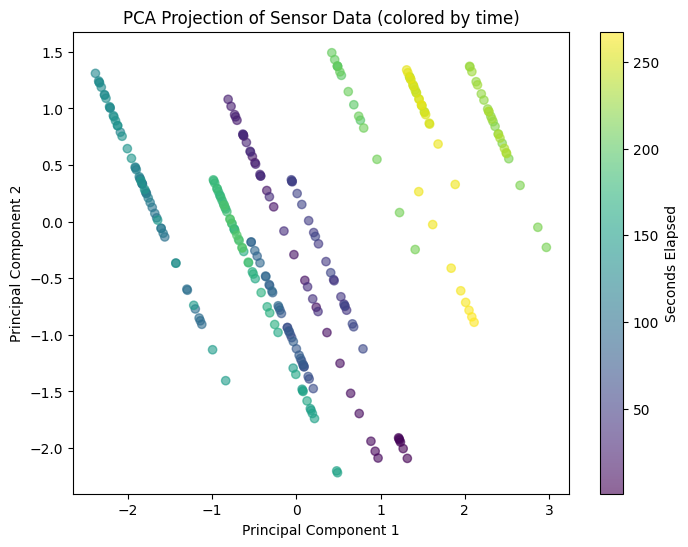

In [12]:
print("PCA Dimensionality Reduction \n")
# PCA with labels and legend
# Select features
features = ['speed','batteryLevel','altitude']
X = merged_df[features].dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Make sure the coloring array matches the PCA shape
color_values = merged_df.loc[X.index, 'seconds_elapsed']

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=color_values, cmap='viridis', alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Sensor Data (colored by time)")
plt.colorbar(scatter, label="Seconds Elapsed")
plt.show()



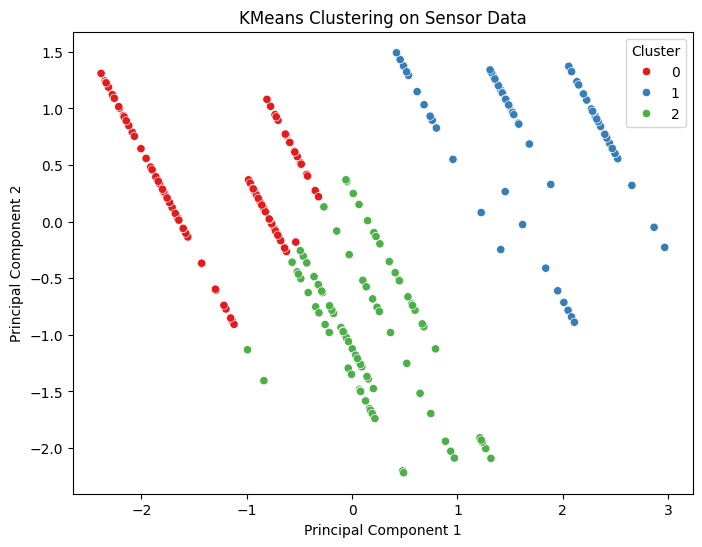

In [14]:
# Run KMeans on the scaled PCA input
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Create a copy of the subset dataframe used for PCA
pca_df = merged_df.loc[X.index].copy()
pca_df['cluster'] = clusters

# Plot clusters in PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=pca_df['cluster'], palette="Set1")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering on Sensor Data")
plt.legend(title="Cluster")
plt.show()


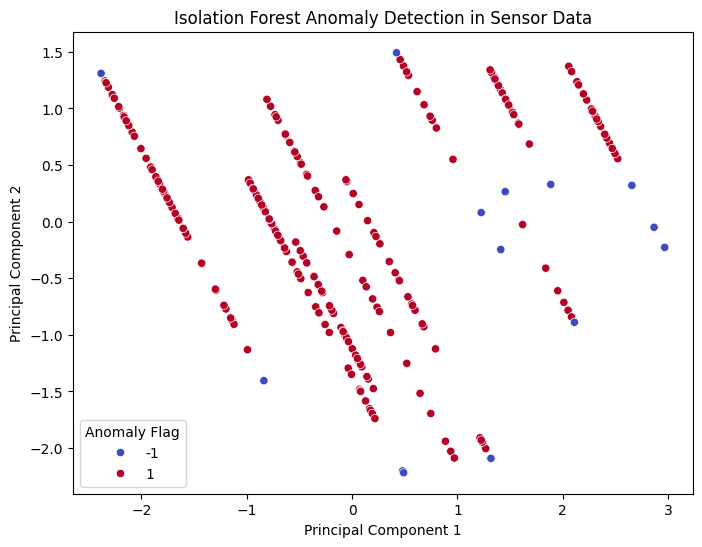

In [16]:
# Run Isolation Forest on the scaled PCA input
iso = IsolationForest(contamination=0.05, random_state=42)
anomalies = iso.fit_predict(X_scaled)

# Create a copy of the subset dataframe used for PCA
pca_df = merged_df.loc[X.index].copy()
pca_df['anomaly'] = anomalies

# Plot anomalies in PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=pca_df['anomaly'], palette="coolwarm")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomaly Detection in Sensor Data")
plt.legend(title="Anomaly Flag")
plt.show()
